In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit import cost

## Problem 1

In [2]:
df = pd.read_csv('Exam_Prob1.txt', sep=' ', header=None, names=['x1', 'x2', 'x3', 'x4', 'x5'])
df

,x1,x2,x3,x4,x5
0,1.252181,0.435551,2.0,0.787337,1.035054
1,0.631197,-0.242014,4.0,1.522948,1.689663
2,1.783390,0.306556,3.0,2.452806,2.649768
3,1.773673,0.041227,2.0,1.160324,1.089209
4,1.658479,0.651232,4.0,2.494915,1.333705
...,...,...,...,...,...
4995,0.658032,-0.046531,2.0,1.204124,3.539424
4996,1.200904,0.191232,1.0,1.538727,4.406046
4997,0.991734,0.169816,5.0,2.217354,3.228582
4998,1.673475,0.005104,1.0,2.127223,2.167343


In [3]:
x1 = df['x1'].values
x2 = df['x2'].values
x3 = df['x3'].values

In [4]:
def f1(x, a):
    return 1/(x+5)*np.sin(a*x)

def f2(x, a):
    return np.sin(a*x)+1

def f3(x, a):
    return np.sin(a*x**2)

def f4(x, a):
    return (np.sin(a*x+1))**2

def f5(x):
    return x*np.tan(x)

def f6(x, a, b):
    return 1 + a*x + b*(x**2)

def f7(x, a, b):
    return a + b*x

def f8(x, mu, sigma):
    return np.exp(-(x-mu)**2/(2*sigma**2))

from scipy.stats import binom, poisson, logser

def f9(k, n, p):
    return binom.pmf(k, n, p)

def f10(k, lamb):
    return poisson.pmf(k, lamb)

def f11(k, p):
    return logser.pmf(k, p)

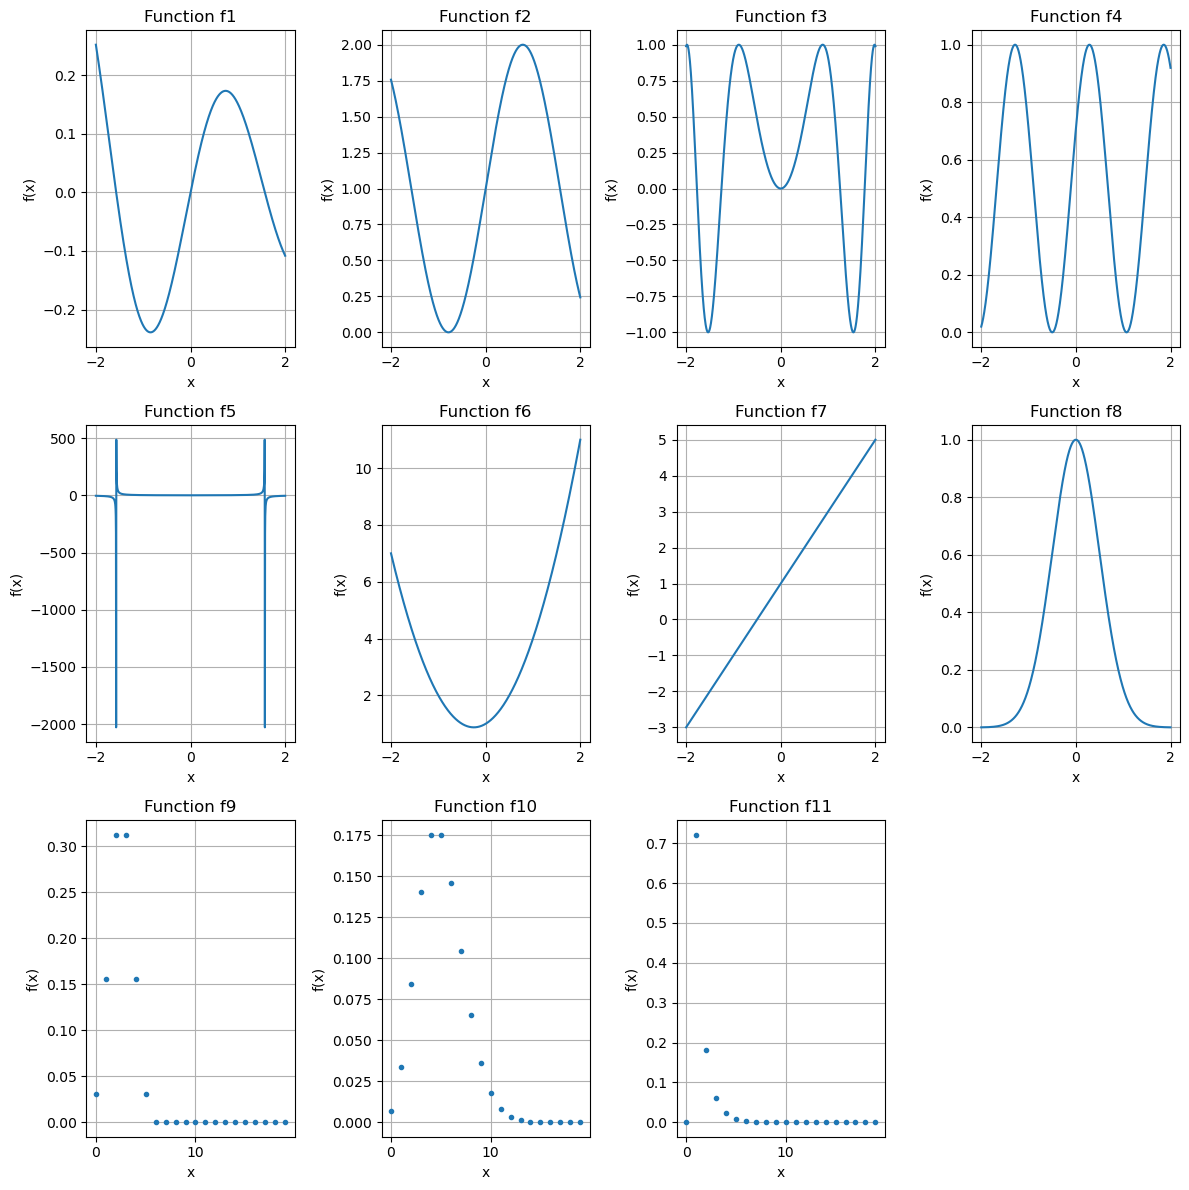

In [5]:
xxCont = np.linspace(-2, 2, 1000)
xxDisc = np.arange(0, 20)
configs = [
    (f1, xxCont, (2,), '-'),
    (f2, xxCont, (2,), '-'),
    (f3, xxCont, (2,), '-'),
    (f4, xxCont, (2,), '-'),
    (f5, xxCont, (), '-'),
    (f6, xxCont, (1, 2), '-'),
    (f7, xxCont, (1, 2), '-'),
    (f8, xxCont, (0, 0.5), '-'),
    (f9, xxDisc, (5, 0.5), '.'),
    (f10, xxDisc, (5,), '.'),
    (f11, xxDisc, (0.5,), '.'),
]

fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flatten()

for i, (f, x, args, style) in enumerate(configs):
    y = f(x, *args)
    ax[i].plot(x, y, style)
    ax[i].set_title(f'Function f{i+1}')
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('f(x)')
    ax[i].grid()

for j in range(len(configs), len(ax)):
    ax[j].axis('off')

plt.tight_layout()

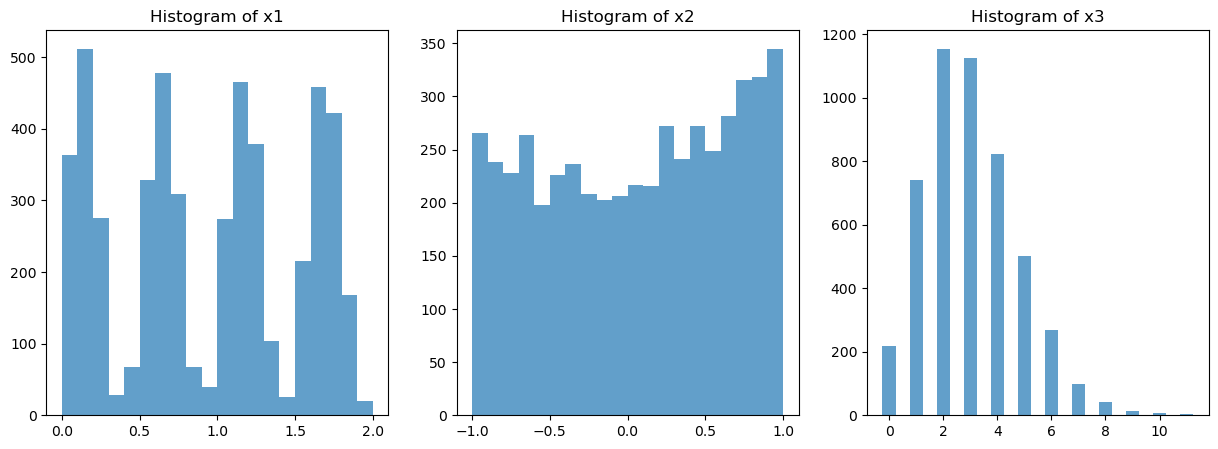

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].hist(x1, bins=20, alpha=0.7)
ax[0].set_title('Histogram of x1')

ax[1].hist(x2, bins=20, alpha=0.7)
ax[1].set_title('Histogram of x2')

x3 = np.array(x3, dtype=int).flatten()

ax[2].bar(np.unique(x3), np.bincount(x3), width=0.5, alpha=0.7)
ax[2].set_title('Histogram of x3');

In [7]:
def raster_scan(cost_func, param_ranges, num_points=100):
    param_names = list(param_ranges.keys())
    n_params = len(param_names)

    grids = [np.linspace(*param_ranges[name], num_points) for name in param_names]

    # 1D scan
    if n_params == 1:
        values = np.array([cost_func(v) for v in grids[0]])/2

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(grids[0], values, color='steelblue')
        ax.set_xlabel(param_names[0])
        ax.set_ylabel('Cost function value')
        ax.set_title(f'Raster Scan — {param_names[0]}')

        best_idx = np.nanargmin(values)         
        best_x   = grids[0][best_idx]
        best_val = values[best_idx]
        ax.axvline(best_x, color='red', ls='--',label=f'Scan min: {param_names[0]} = {best_x:.3f} (NLL={best_val:.2f})')
        ax.legend();

    # 2D scan 
    if n_params == 2:
        g0, g1 = np.meshgrid(grids[0], grids[1])
        points  = np.vstack([g0.ravel(), g1.ravel()]).T
        values  = np.array([cost_func(p[0], p[1]) for p in points]).reshape(g0.shape)/2

        fig, ax = plt.subplots(figsize=(8, 6))
        pcm = ax.pcolormesh(g0, g1, values, cmap='plasma', shading='auto')
        plt.colorbar(pcm, ax=ax, label='Cost function value')

        flat_idx  = np.nanargmin(values)                         
        best_idx  = np.unravel_index(flat_idx, values.shape)      
        best_x    = g0[best_idx]
        best_y    = g1[best_idx]
        best_val  = values[best_idx]
        ax.plot(best_x, best_y, 'r*', ms=14, label=f'Scan min: ({best_x:.3f}, {best_y:.3f})  NLL={best_val:.2f}')
        ax.set_xlabel(param_names[0])
        ax.set_ylabel(param_names[1])
        ax.set_title('Raster Scan — ' + ' vs '.join(np.flipud(param_names)))
        ax.legend();

In [8]:
from scipy.integrate import quad

def f4_norm(x, a):
    N1 = quad(lambda x: f4(x, a), 0, 2)
    return f4(x, a)/N1[0]

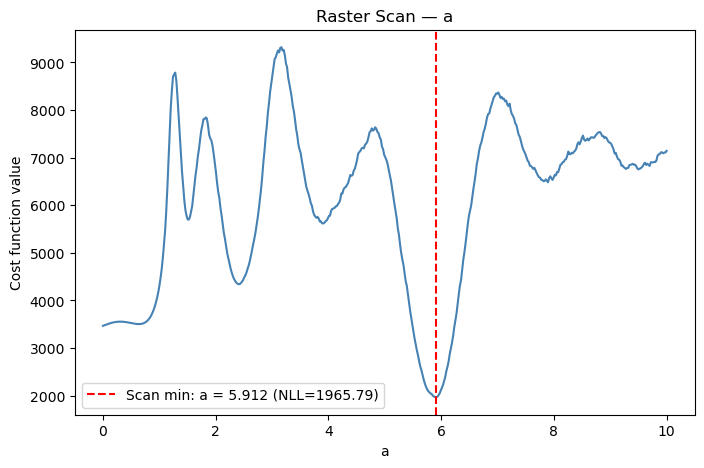

In [9]:
c1 = cost.UnbinnedNLL(x1, f4_norm)
raster_scan(c1, {'a': (0, 10)}, num_points=500);

In [10]:
m1 = Minuit(c1, a=6)
m1.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3929                       │              Nfcn = 22               │
│ EDM = 1.83e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   5.904   │   0.005   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────┐
│   │       a │
├───┼─────────┤
│ a │ 2.5e-05 │
└───┴─────────┘

In [11]:
def poly2_truncated(x, a, b):
    def unnorm(t):
        return b * t**2 + a * t + 1

    # Analytic normalization over [-1, 1]
    Z = (2/3) * b + 2

    return unnorm(x) / Z

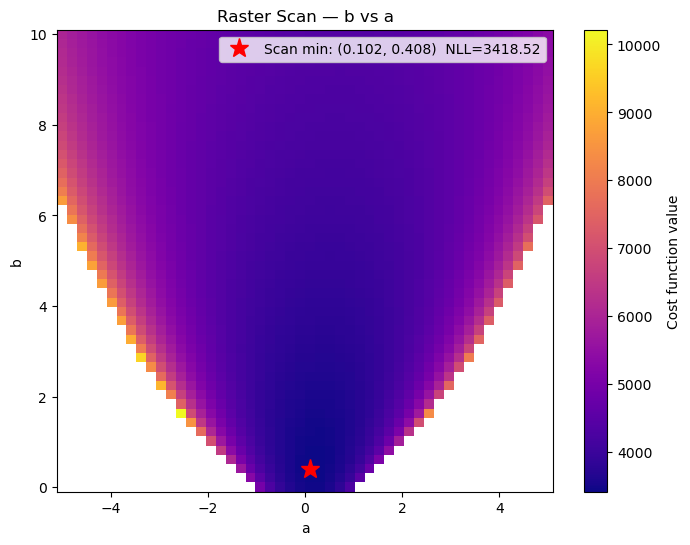

In [12]:
c2 = cost.UnbinnedNLL(x2, poly2_truncated)
raster_scan(c2, {'a': (-5,5), 'b': (0, 10)}, num_points=50);

In [13]:
m2 = Minuit(c2, a=0.1, b=0.4)
m2.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6826                       │              Nfcn = 36               │
│ EDM = 1.47e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ a    │   0.198   │   0.029   │            │            │         │         │       │
│ 1 │ b    │   0.42    │   0.06    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        a        b │
├───┼───────────────────┤
│ a │ 0.000869   0.4e-3 │
│ b │   0.4e-3  0.00399 │
└───┴───────────────────┘

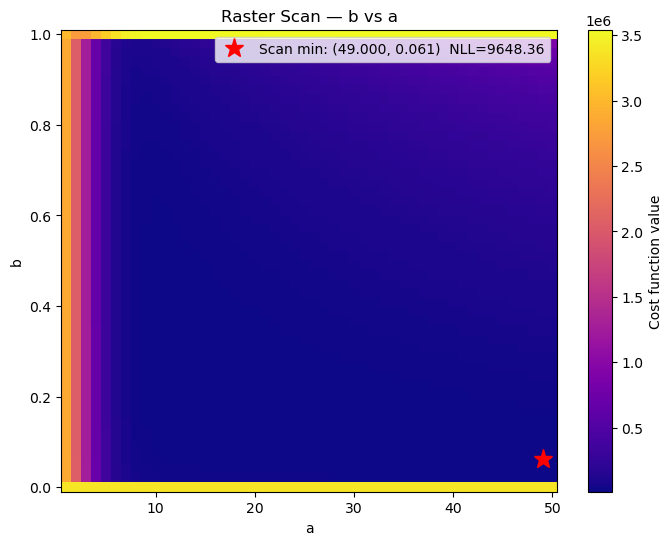

In [38]:
c3 = cost.UnbinnedNLL(x3, f9)
raster_scan(c3, {'a': (1,50), 'b': (0, 1) }, num_points=50);

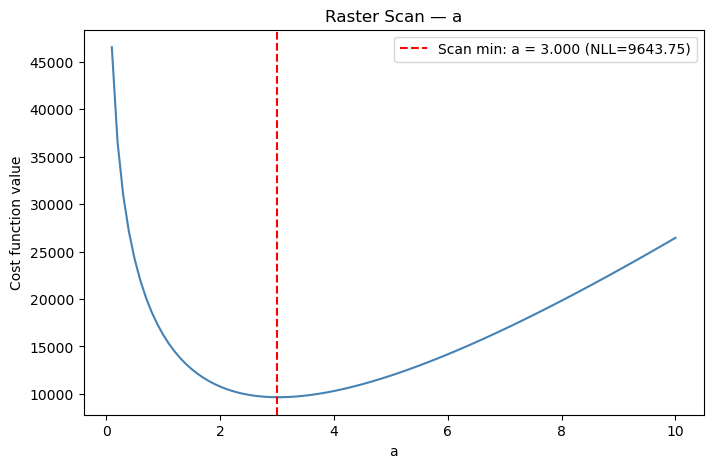

In [39]:
c3 = cost.UnbinnedNLL(x3, f10)
raster_scan(c3, {'a': (0.1,10)}, num_points=100);

In [40]:
m3 = Minuit(c3, lamb=3)
m3.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.929e+04                  │              Nfcn = 11               │
│ EDM = 4.54e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ lamb │   3.022   │   0.025   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────┬──────────┐
│      │     lamb │
├──────┼──────────┤
│ lamb │ 0.000604 │
└──────┴──────────┘

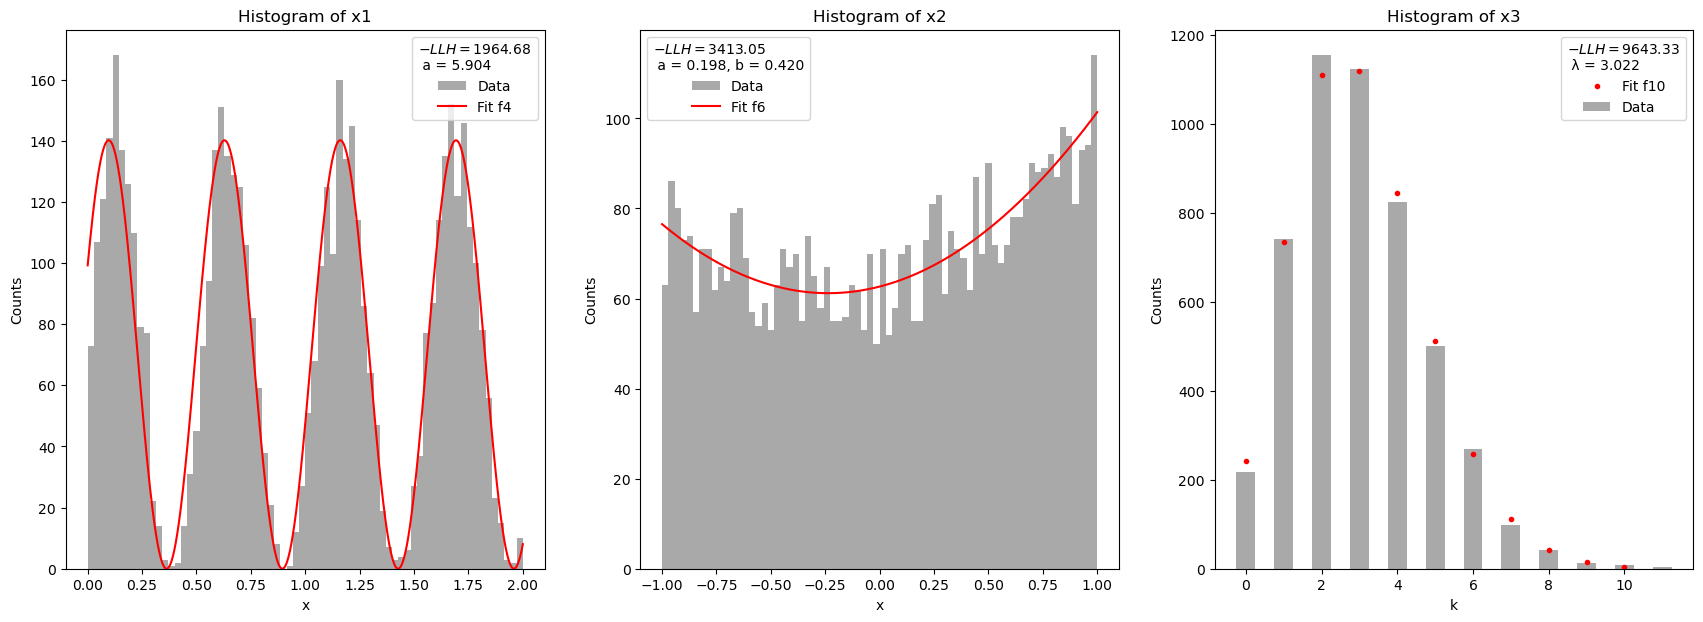

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(21, 7))

xx1 = np.linspace(0, 2, 1000)
xmin1 = 0
xmax1 = 2
binwidth1 = (xmax1 - xmin1) / 70
ax[0].hist(x1, bins=70, range=(xmin1, xmax1), color='darkgray', label='Data')
ax[0].set_title(f'Histogram of x1')
ax[0].plot(xx1, f4_norm(xx1, m1.values['a'])*len(x1)*binwidth1, 'r-', label='Fit f4')
ax[0].legend(title=f"$-LLH = {m1.fval/2:.2f}$ \n a = {m1.values['a']:.3f}")
ax[0].set_xlabel('x')
ax[0].set_ylabel('Counts')

xx2 = np.linspace(-1, 1, 1000)
xmin2 = -1
xmax2 = 1
binwidth2 = (xmax2 - xmin2) / 70
ax[1].hist(x2, bins=70, range=(xmin2, xmax2), color='darkgray', label='Data')
ax[1].set_title(f'Histogram of x2')
ax[1].plot(xx2, poly2_truncated(xx2, m2.values['a'], m2.values['b'])*len(x2)*binwidth2, 'r-', label='Fit f6')
ax[1].legend(title=f"$-LLH = {m2.fval/2:.2f}$ \n a = {m2.values['a']:.3f}, b = {m2.values['b']:.3f}")
ax[1].set_xlabel('x')
ax[1].set_ylabel('Counts')

x3 = np.array(x3, dtype=int).flatten()
xx3 = np.arange(0, 11)
ax[2].bar(np.unique(x3), np.bincount(x3), width=0.5, color='darkgray', label='Data')
ax[2].set_title('Histogram of x3')
ax[2].plot(xx3, f10(xx3, m3.values['lamb'])*len(x3), 'r.', label='Fit f10')
ax[2].legend(title=f"$-LLH = {m3.fval/2:.2f}$ \n λ = {m3.values['lamb']:.3f}")
ax[2].set_xlabel('k')
ax[2].set_ylabel('Counts');

## Problem 2

In [17]:
from sklearn import tree
from sklearn.ensemble import AdaBoostClassifier

In [18]:
trainTest = pd.read_csv('breast_cancer_wisconsin_train_test.txt', sep=' ', header=None, names=['id', 'clump_thickness', 'cell_size_uniformity', 'cell_shape_uniformity', 'marginal_adhesion', 'single_epithelial_cell_size', 'bare_nuclei', 'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class'])
benign = trainTest[trainTest['class'] == 2]
malignant = trainTest[trainTest['class'] == 4]
benign = benign.drop(columns=['id', 'class'])
malignant = malignant.drop(columns=['id', 'class'])
print("Number of benign cases: ", len(benign))
print("Number of malignant cases: ", len(malignant))

Number of benign cases:  100
Number of malignant cases:  100


In [107]:
X_train = np.vstack([benign, malignant])
y_train = np.concatenate([np.zeros(len(benign)), np.ones(len(malignant))])

clf = AdaBoostClassifier(
    estimator=tree.DecisionTreeClassifier(max_depth=2),
    n_estimators=50,
    learning_rate=0.3,
    random_state=42
)
clf.fit(X_train, y_train)


bdt_score_train = clf.decision_function(X_train)

low_scores = bdt_score_train[y_train == 0]
high_scores = bdt_score_train[y_train == 1]

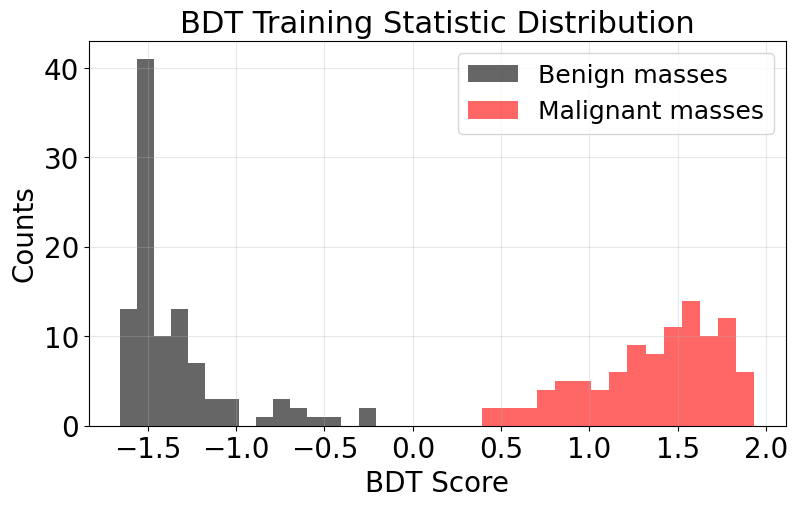

In [108]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(low_scores, bins=15, alpha=0.6, label='Benign masses', color='black')
ax.hist(high_scores, bins=15, alpha=0.6, label='Malignant masses', color='red')
ax.set_xlabel("BDT Score", fontsize=20)
ax.set_ylabel("Counts", fontsize=20)
ax.set_title("BDT Training Statistic Distribution", fontsize=22)
ax.tick_params(labelsize=20)
ax.legend(fontsize=18)
ax.grid(alpha=0.3);

In [21]:
y_pred_train = (bdt_score_train > 0).astype(int)

accuracy = np.mean(y_pred_train == y_train)
print("Training accuracy:", accuracy)

Training accuracy: 1.0


In [22]:
realData = pd.read_csv('breast_cancer_wisconsin_mod_real.txt', sep=' ', header=None, names=['id', 'clump_thickness', 'cell_size_uniformity', 'cell_shape_uniformity', 'marginal_adhesion', 'single_epithelial_cell_size', 'bare_nuclei', 'bland_chromatin', 'normal_nucleoli', 'mitoses'])
IDs = realData["id"].values
realData

,id,clump_thickness,cell_size_uniformity,cell_shape_uniformity,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses
0,29587444,8.0,2.0,1.0,1.0,5.0,1.0,1.0,1.0,1.0
1,1387972,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0
2,31320505,4.0,1.0,3.0,3.0,2.0,1.0,1.0,1.0,1.0
3,27192667,8.0,10.0,3.0,2.0,6.0,4.0,3.0,10.0,1.0
4,21723069,10.0,10.0,6.0,3.0,3.0,10.0,4.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...
478,24026203,5.0,10.0,10.0,10.0,10.0,2.0,10.0,10.0,10.0
479,10087854,1.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0
480,18356947,5.0,1.0,1.0,1.0,3.0,2.0,2.0,2.0,1.0
481,15290053,5.0,2.0,2.0,2.0,3.0,1.0,1.0,3.0,1.0


In [23]:
realDataTest = realData.drop(columns=["id"])
realDataTest

,clump_thickness,cell_size_uniformity,cell_shape_uniformity,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses
0,8.0,2.0,1.0,1.0,5.0,1.0,1.0,1.0,1.0
1,2.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,1.0
2,4.0,1.0,3.0,3.0,2.0,1.0,1.0,1.0,1.0
3,8.0,10.0,3.0,2.0,6.0,4.0,3.0,10.0,1.0
4,10.0,10.0,6.0,3.0,3.0,10.0,4.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...
478,5.0,10.0,10.0,10.0,10.0,2.0,10.0,10.0,10.0
479,1.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0
480,5.0,1.0,1.0,1.0,3.0,2.0,2.0,2.0,1.0
481,5.0,2.0,2.0,2.0,3.0,1.0,1.0,3.0,1.0


In [24]:
bdt_score_real = clf.decision_function(realDataTest.values)

In [120]:
benignReal = IDs[bdt_score_real <= 0]
malignantReal = IDs[bdt_score_real > 0]
print("Benign in real data:", len(benignReal), '->', len(benignReal)/(len(realData)))
print("Malignant in real data:", len(malignantReal), '->', len(malignantReal)/(len(realData)))
np.savetxt("sagar_clemensen.benign_ID.txt", benignReal)
np.savetxt("sagar_clemensen.malignant_ID.txt", malignantReal)

Benign in real data: 332 -> 0.6873706004140787
Malignant in real data: 151 -> 0.31262939958592134


## Problem 3

In [26]:
df3 = pd.read_csv('Exam_Prob3.txt', sep=' ', header=None, names=['x'])
df3

,x
0,9.198453
1,4.043779
2,7.853886
3,6.062479
4,5.183587
...,...
395,1.328555
396,3.200075
397,3.733619
398,8.132878


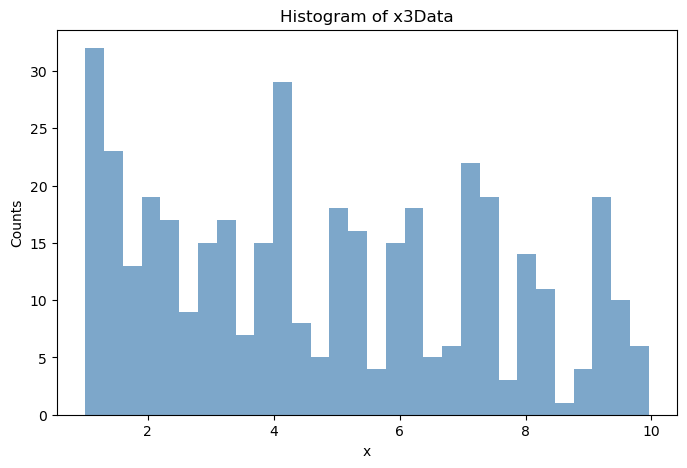

In [27]:
x3Data = df3['x'].values
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(x3Data, bins=30, alpha=0.7, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('Counts')
ax.set_title('Histogram of x3Data');

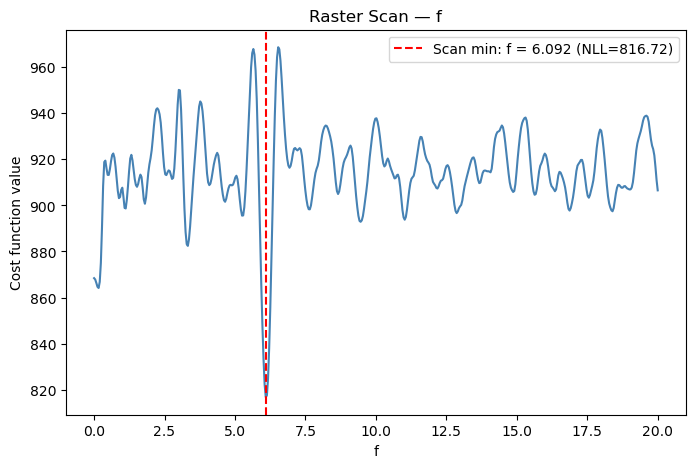

In [28]:
def G(x, f):
    N = (np.sin(10*f)-np.sin(f))/f + 9 + np.log(1331/8)
    return 1/N * (np.cos(f*x) + 3/(x+1) +1)

cNew = cost.UnbinnedNLL(x3Data, G)
raster_scan(cNew, {'f': (0.0001, 20)}, num_points=500);

100%|██████████| 10000/10000 [00:23<00:00, 433.73it/s]


MAP estimate:     16.8618
Posterior mean:   15.5048
Posterior median: 15.6515
Posterior std:    1.4472
95% CI:           [12.84765182 16.91389127]


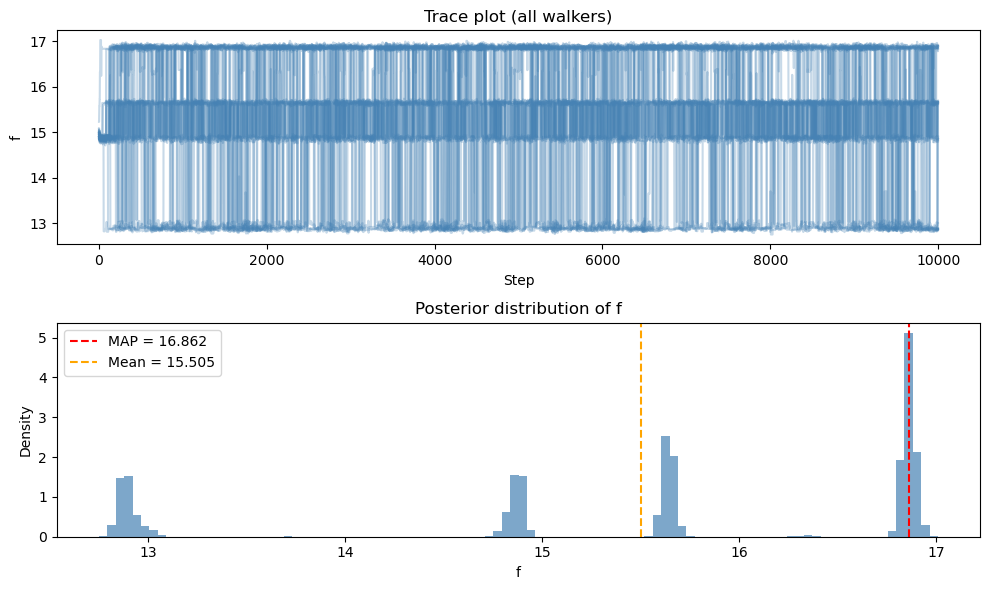


Mean acceptance fraction: 0.280
Chain too short to estimate autocorrelation time — increase nsteps


In [ ]:
import emcee
from scipy.stats import norm

def log_likelihood(f, data):
    N = (np.sin(10*f) - np.sin(f)) / f + 9 + np.log(1331/8)
    G = (1/N) * (np.cos(f * data) + 3/(data + 1) + 1)
    if np.any(G <= 0):
        return -np.inf
    return np.sum(np.log(G))

def log_prior(f):
    if f <= 0 or f > 20: #Truncation
        return -np.inf
    return np.log(norm.pdf(f, loc=15, scale=0.5))

def log_posterior(theta, data):
    f = theta[0]
    lp = log_prior(f)
    return lp + log_likelihood(f, data)

ndim = 1
nwalkers = 32
nsteps = 10000
burnin = 2000

p0 = 15.0 + 0.1 * np.random.randn(nwalkers, ndim)


sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=[x3Data])
sampler.run_mcmc(p0, nsteps, progress=True)

samples = sampler.get_chain(discard=burnin, flat=True)
f_samples = samples[:, 0]


map_idx = np.argmax([log_posterior([f], x3Data) for f in f_samples])
print(f"MAP estimate:     {f_samples[map_idx]:.4f}")
print(f"Posterior mean:   {np.mean(f_samples):.4f}")
print(f"Posterior median: {np.median(f_samples):.4f}")
print(f"Posterior std:    {np.std(f_samples):.4f}")
print(f"95% CI:           {np.percentile(f_samples, [2.5, 97.5])}")

# --- Diagnostics ---
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Trace plot — check walkers mixed well
chain = sampler.get_chain(discard=burnin)  # shape: (steps, walkers, ndim)
axes[0].plot(chain[:, :, 0], alpha=0.3, color="steelblue")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("f")
axes[0].set_title("Trace plot (all walkers)")

# Posterior histogram
axes[1].hist(f_samples, bins=100, density=True, color="steelblue", alpha=0.7)
axes[1].axvline(f_samples[map_idx], color="red", linestyle="--", label=f"MAP = {f_samples[map_idx]:.3f}")
axes[1].axvline(np.mean(f_samples), color="orange", linestyle="--", label=f"Mean = {np.mean(f_samples):.3f}")
axes[1].set_xlabel("f"); axes[1].set_ylabel("Density")
axes[1].set_title("Posterior distribution of f")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Acceptance fraction (should be between 0.2 and 0.5) ---
print(f"\nMean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")

# --- Autocorrelation time (rough convergence check) ---
try:
    tau = sampler.get_autocorr_time()
    print(f"Autocorrelation time: {tau[0]:.1f} steps")
    print(f"Effective samples: {len(f_samples) / tau[0]:.0f}")
except emcee.autocorr.AutocorrError:
    print("Chain too short to estimate autocorrelation time — increase nsteps")

## 3c

100%|██████████| 10000/10000 [00:21<00:00, 456.91it/s]


MAP estimate:     6.1076
Posterior mean:   5.9245
Posterior median: 6.1070
Posterior std:    1.0470
95% CI:           [0.15858537 6.13870643]


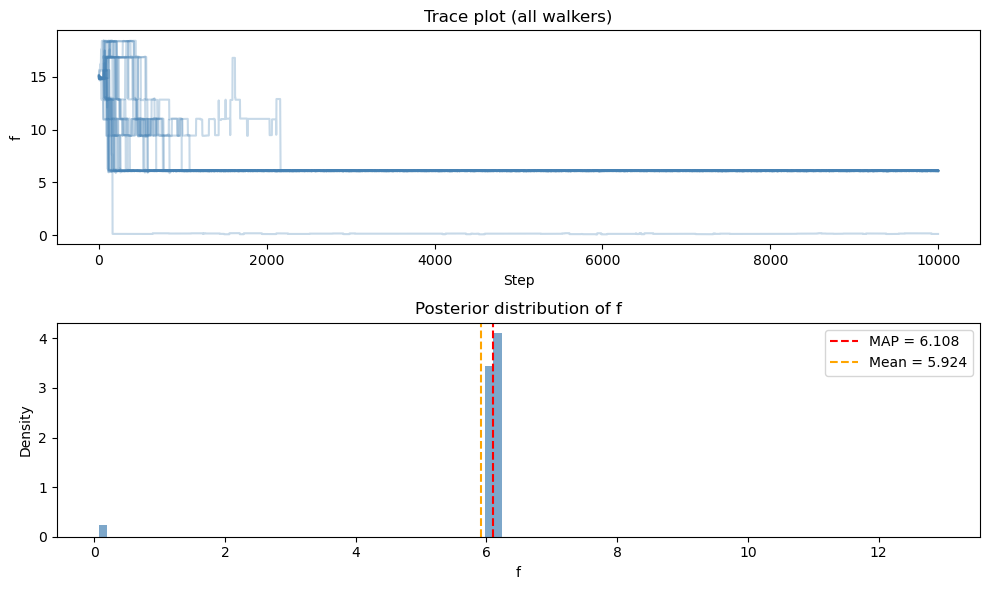


Mean acceptance fraction: 0.716
Chain too short to estimate autocorrelation time — increase nsteps


In [ ]:
def log_priorV2(f):
    if f <= 0 or f > 20: #Truncation
        return -np.inf
    return np.log(norm.pdf(f, loc=15, scale=2.5))

def log_posteriorV2(theta, data):
    f = theta[0]
    lp = log_priorV2(f)
    return lp + log_likelihood(f, data)

ndim = 1
nwalkers = 32
nsteps = 10000
burnin = 2000

p0 = 15.0 + 0.1 * np.random.randn(nwalkers, ndim)


sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posteriorV2, args=[x3Data])
sampler.run_mcmc(p0, nsteps, progress=True)

samples = sampler.get_chain(discard=burnin, flat=True)
f_samples = samples[:, 0]


map_idx = np.argmax([log_posteriorV2([f], x3Data) for f in f_samples])
print(f"MAP estimate:     {f_samples[map_idx]:.4f}")
print(f"Posterior mean:   {np.mean(f_samples):.4f}")
print(f"Posterior median: {np.median(f_samples):.4f}")
print(f"Posterior std:    {np.std(f_samples):.4f}")
print(f"95% CI:           {np.percentile(f_samples, [2.5, 97.5])}")

# --- Diagnostics ---
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Trace plot — check walkers mixed well
chain = sampler.get_chain(discard=burnin)  # shape: (steps, walkers, ndim)
axes[0].plot(chain[:, :, 0], alpha=0.3, color="steelblue")
axes[0].set_xlabel("Step"); axes[0].set_ylabel("f")
axes[0].set_title("Trace plot (all walkers)")

# Posterior histogram
axes[1].hist(f_samples, bins=100, density=True, color="steelblue", alpha=0.7)
axes[1].axvline(f_samples[map_idx], color="red", linestyle="--", label=f"MAP = {f_samples[map_idx]:.3f}")
axes[1].axvline(np.mean(f_samples), color="orange", linestyle="--", label=f"Mean = {np.mean(f_samples):.3f}")
axes[1].set_xlabel("f"); axes[1].set_ylabel("Density")
axes[1].set_title("Posterior distribution of f")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Acceptance fraction (should be between 0.2 and 0.5) ---
print(f"\nMean acceptance fraction: {np.mean(sampler.acceptance_fraction):.3f}")

# --- Autocorrelation time (rough convergence check) ---
try:
    tau = sampler.get_autocorr_time()
    print(f"Autocorrelation time: {tau[0]:.1f} steps")
    print(f"Effective samples: {len(f_samples) / tau[0]:.0f}")
except emcee.autocorr.AutocorrError:
    print("Chain too short to estimate autocorrelation time — increase nsteps")

## Problem 4

### 4a

In [ ]:
def damage(Edam):
    return poisson.rvs(Edam)

def BattleSimulation(Edam, life, Ntrials):
    np.random.seed(42)
    Ndefeated = np.zeros(Ntrials)
    
    for i in range(Ntrials):
        totDam = 0
        defeats = 0
        for j in range(6):
            dam = damage(Edam)
            if dam == 0:
                dam = 1
            totDam += dam
            if totDam >= life:
                totDam = 0
                defeats += 1
        Ndefeated[i] = defeats
    return Ndefeated

In [49]:
Ndefeats = BattleSimulation(5, 12, 1000)

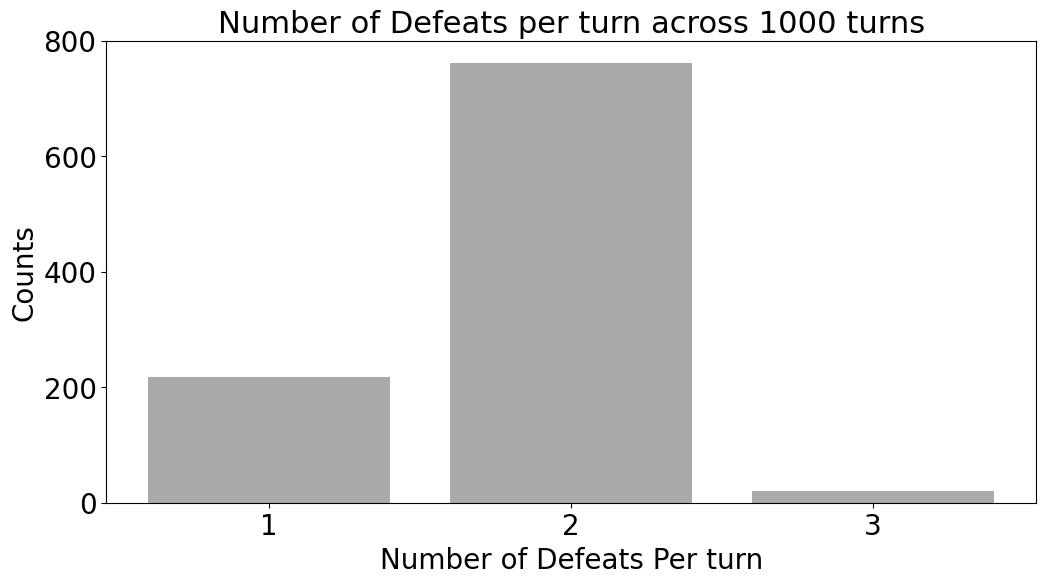

In [50]:
uniqueDefeats, defeatCounts = np.unique(Ndefeats, return_counts=True)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(uniqueDefeats, defeatCounts, color='darkgray', width=0.8)
ax.set_xlabel('Number of Defeats Per turn', fontsize=20)
ax.set_ylabel('Counts', fontsize=20)
ax.set_title('Number of Defeats per turn across 1000 turns', fontsize=22)
ax.set_xticks(uniqueDefeats)
ax.tick_params(axis='both', which='major', labelsize=20)

### 4b

In [56]:
def BattleSimulationV2(Edam, life, Ntrials, accuracy):
    np.random.seed(42)
    Ndefeated = np.zeros(Ntrials)
    for i in range(Ntrials):
        totDam = 0
        defeats = 0
        for j in range(6):
            dam = damage(Edam)
            if dam == 0:
                dam = 1
            if accuracy[j] < np.random.rand():
                dam = 0
            totDam += dam
            if totDam >= life:
                totDam = 0
                defeats += 1
        Ndefeated[i] = defeats
    return Ndefeated

In [64]:
accuracyVals = np.array([0.9, 0.8, 0.6, 0.9, 0.6, 0.7])
NdefeatedV2 = BattleSimulationV2(5, 12, 5000, accuracyVals)

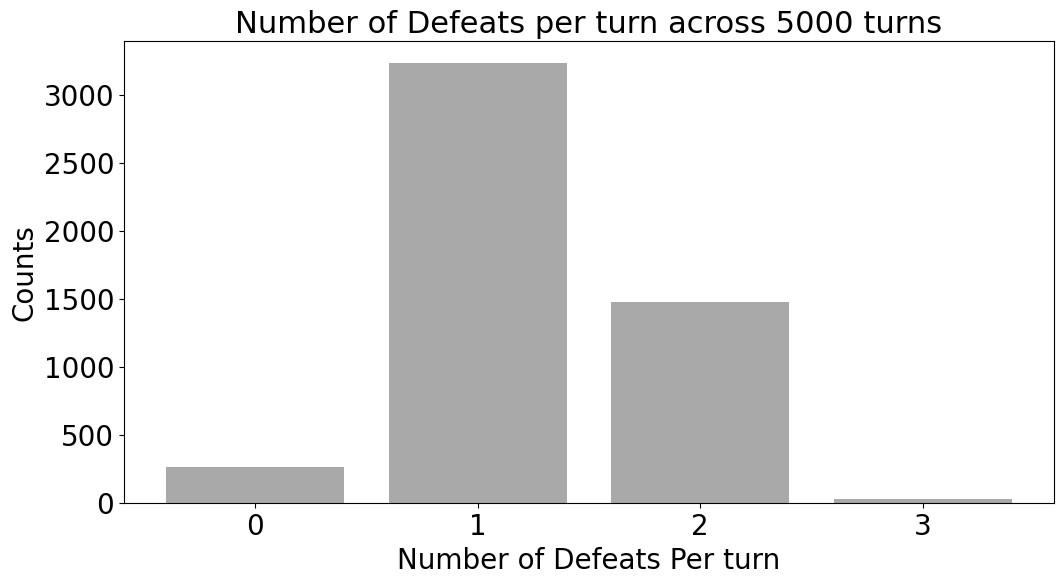

In [65]:
uniqueDefeats, defeatCounts = np.unique(NdefeatedV2, return_counts=True)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(uniqueDefeats, defeatCounts, color='darkgray', width=0.8)
ax.set_xlabel('Number of Defeats Per turn', fontsize=20)
ax.set_ylabel('Counts', fontsize=20)
ax.set_title('Number of Defeats per turn across 5000 turns', fontsize=22)
ax.set_xticks(uniqueDefeats)
ax.tick_params(axis='both', which='major', labelsize=20)

In [71]:
Nturns = 5000
noDefeats = np.sum(NdefeatedV2 == 0)
frac = noDefeats / Nturns
dfrac = np.sqrt(frac*(1-frac)/Nturns)
frac *= 100
dfrac *= 100
print(f"Fraction of turns without defeat: {frac:.4f}% ± {dfrac:.4f}%")

Fraction of turns without defeat: 5.2000% ± 0.3140%


### 4c

In [72]:
accuracyAscend = np.sort(accuracyVals)
accuracyDescend = np.flipud(accuracyAscend)
print("Accuracy ascending:", accuracyAscend)
print("Accuracy descending:", accuracyDescend)

Accuracy ascending: [0.6 0.6 0.7 0.8 0.9 0.9]
Accuracy descending: [0.9 0.9 0.8 0.7 0.6 0.6]


In [75]:
NdefeatedSortList = []
for order, accs in zip(["Ascending", "Descending"], [accuracyAscend, accuracyDescend]):
    NdefeatedSort = BattleSimulationV2(5, 12, 5000, accs)
    NdefeatedSortList.append(NdefeatedSort)
    noDefeatsSort = np.sum(NdefeatedSort == 0)
    fracSort = noDefeatsSort / Nturns
    dfracSort = np.sqrt(fracSort*(1-fracSort)/Nturns)
    fracSort *= 100
    dfracSort *= 100
    print(f"Fraction of turns without defeat ({order}): {fracSort:.4f}% ± {dfracSort:.4f}%")
    zval = np.abs(frac - fracSort) / np.sqrt(dfrac**2 + dfracSort**2)
    print(f"Z-value comparing {order} to original: {zval:.2f}")
    pval = 2 * (1 - norm.cdf(zval))
    print(f"P-value comparing {order} to original: {pval:.4f}", "\n")

Fraction of turns without defeat (Ascending): 5.1600% ± 0.3128%
Z-value comparing Ascending to original: 0.09
P-value comparing Ascending to original: 0.9281 

Fraction of turns without defeat (Descending): 5.1600% ± 0.3128%
Z-value comparing Descending to original: 0.09
P-value comparing Descending to original: 0.9281 



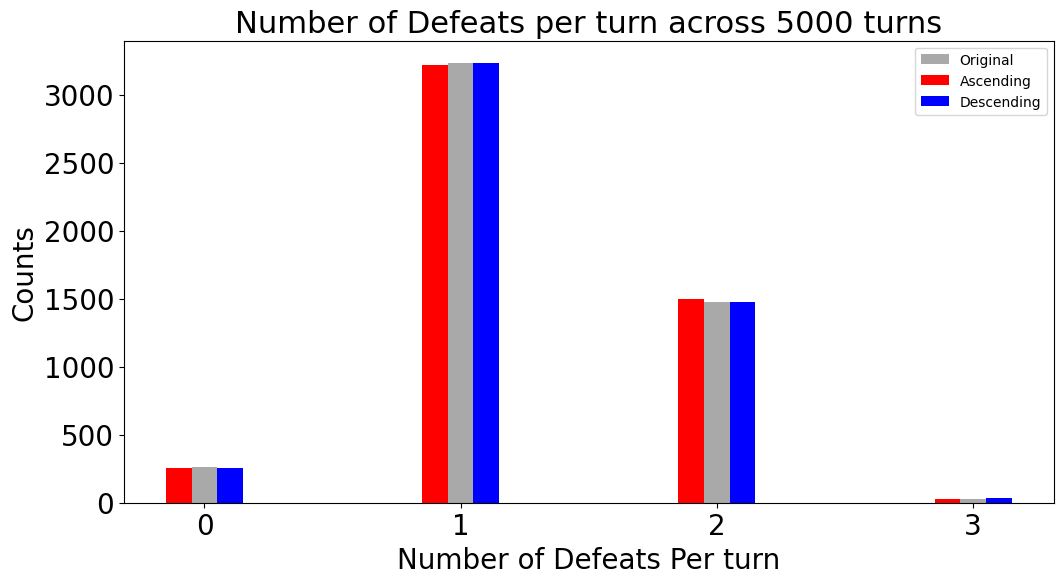

In [92]:
uniqueDefeatsSortA, defeatCountsSortA = np.unique(NdefeatedSortList[0], return_counts=True)
uniqueDefeatsSortB, defeatCountsSortB = np.unique(NdefeatedSortList[1], return_counts=True)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(uniqueDefeats, defeatCounts, width=0.1, color='darkgray', label='Original')
ax.bar(uniqueDefeatsSortA - 0.1, defeatCountsSortA, width=0.1, color='red', label='Ascending')
ax.bar(uniqueDefeatsSortB + 0.1, defeatCountsSortB, width=0.1, color='blue', label='Descending')
ax.set_xlabel('Number of Defeats Per turn', fontsize=20)
ax.set_ylabel('Counts', fontsize=20)
ax.set_title('Number of Defeats per turn across 5000 turns', fontsize=22)
ax.set_xticks(uniqueDefeats)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend();

## Problem 5

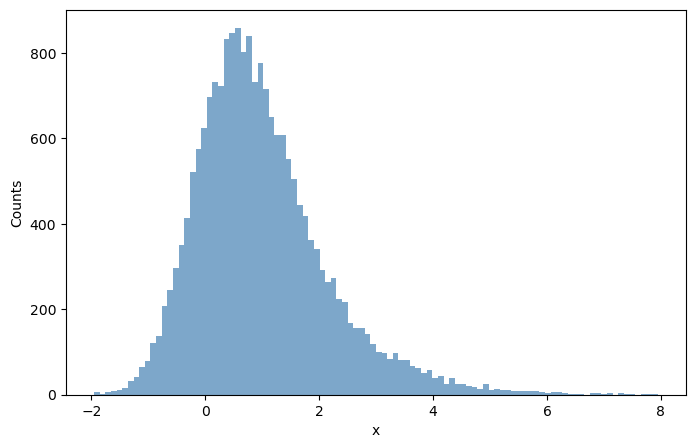

In [2]:
df5 = pd.read_csv('Exam_Prob5_NucData.txt', sep=' ', header=None, names=['x'])
x5 = df5['x'].values
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(x5, bins=100, alpha=0.7, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('Counts');

In [3]:
from scipy.special import erfc
def pdf(t, b, sigma):
    return 1/(2*b) * np.exp(sigma**2/(2*b**2) - t/b) * erfc(sigma/(np.sqrt(2)*b) - t/(np.sqrt(2)*sigma))

In [4]:
data1 = x5[:200]
c5 = cost.UnbinnedNLL(data1, pdf)
m5 = Minuit(c5, b=0.1, sigma=1)
m5.limits['b'] = (0.1, 5)
m5.limits['sigma'] = (0.1, 5)
m5.migrad()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 583.3                      │              Nfcn = 58               │
│ EDM = 4.11e-06 (Goal: 0.0002)    │            time = 0.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬───────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name  │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼───────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ b     │   1.01    │   0.08    │            │            │   0.1   │    5    │       │
│ 1 │ sigma │   0.59    │   0.06    │            │            │   0.1   │    5    │       │
└───┴───────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───────┬─────────────────┐
│       │       b   sigma │
├───────┼─────────────────┤
│     b │ 0.00663  -0.001 │
│ sigma │  -0.001 0.00411 │
└───────┴─────────────────┘

In [5]:
lambdas = np.zeros(100)
for i in range(100):
    data = x5[i*200:200*(i+1)]
    
    c = cost.UnbinnedNLL(data, pdf)
    
    mNull = Minuit(c, b=1, sigma=1)
    mNull.fixed['b'] = True 
    mNull.limits['sigma'] = (0.1, 10)
    mNull.migrad()
    
    mAlt = Minuit(c, b=1, sigma=1)
    mAlt.limits['b'] = (0.1, 10)
    mAlt.limits['sigma'] = (0.1, 10)
    mAlt.migrad()
    
    lambVal = mNull.fval - mAlt.fval
    lambdas[i] = lambVal

In [7]:
print(np.min(lambdas), np.max(lambdas), np.mean(lambdas), np.std(lambdas))

-3.2191345553655992e-06 5.978907331218011 0.9492692880252832 1.1658015906827215


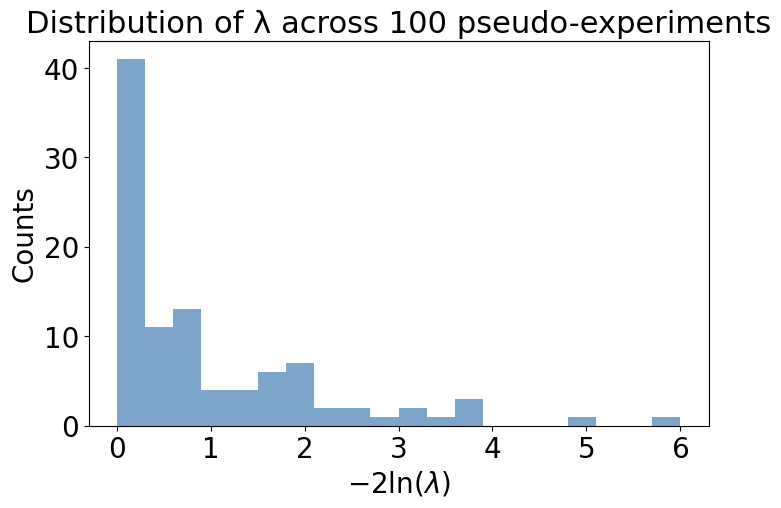

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
xmin = 0
xmax = 6
ax.hist(lambdas, bins=20, range=(xmin, xmax), alpha=0.7, color='steelblue')
ax.set_xlabel(r'$-2\ln(\lambda)$', fontsize=20)
ax.set_ylabel('Counts', fontsize=20)
ax.set_title('Distribution of λ across 100 pseudo-experiments', fontsize=22)
ax.tick_params(labelsize=20);

In [196]:
from scipy.stats import chi2
print(f"The expected number of pseudo-experiments with -2ln(λ) > 2.706: {chi2.sf(2.706, df=1)*100}")
print(f"Number of pseudo-experiments with -2ln(λ) > 2.706: {np.sum(lambdas > 2.706)} out of 100")

The expected number of pseudo-experiments with -2ln(λ) > 2.706: 9.99713781252592
Number of pseudo-experiments with -2ln(λ) > 2.706: 9 out of 100


In [197]:
cNull = cost.UnbinnedNLL(x5, pdf)
mNull = Minuit(cNull, b=1, sigma=1)
mNull.fixed['b'] = True 
mNull.limits['sigma'] = (0.1, 10)
mNull.migrad()

cAlt = cost.UnbinnedNLL(x5, pdf)
mAlt = Minuit(cAlt, b=1, sigma=1)
mAlt.limits['b'] = (0.1, 10)
mAlt.limits['sigma'] = (0.1, 10)
mAlt.migrad()

lambVal = mNull.fval - mAlt.fval
print(f"-2ln(λ) for real data: {lambVal:.2f}")

-2ln(λ) for real data: 2.27


In [ ]:
# It is below 2.30 which is the 2sigma threshold, so the null hypothesis can not be rejected at 3sigma level